В этой части находится самостоятельная работа к ЛБ4 по построению модели используя нейронные сети

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

import pandas as pd

In [5]:
df_train = pd.read_excel("data/predict_house_price_training_data.xlsx")
df_test = pd.read_excel("data/predict_house_price_test_data.xlsx")

In [6]:
df_train.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,830000,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,385000,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,610000,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,550000,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,1300000,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


In [7]:
df_test.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,260000,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,734500,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,325000,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,1990000,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,315000,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         6484 non-null   int64  
 1   Спальни              6484 non-null   int64  
 2   Ванные               6484 non-null   float64
 3   Жилая площадь        6484 non-null   int64  
 4   Общая площадь        6484 non-null   int64  
 5   Количество этажей    6484 non-null   float64
 6   Вид на воду          6484 non-null   int64  
 7   Просмотрены ранее    6484 non-null   int64  
 8   Состояние            6484 non-null   int64  
 9   Оценка риелтора      6484 non-null   int64  
 10  Площадь без подвала  6484 non-null   int64  
 11  Площадь подвала      6484 non-null   int64  
 12  Год постройки        6484 non-null   int64  
 13  Год реновации        6484 non-null   int64  
 14  Широта               6484 non-null   float64
 15  Долгота              6484 non-null   f

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15129 entries, 0 to 15128
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         15129 non-null  int64  
 1   Спальни              15129 non-null  int64  
 2   Ванные               15129 non-null  float64
 3   Жилая площадь        15129 non-null  int64  
 4   Общая площадь        15129 non-null  int64  
 5   Количество этажей    15129 non-null  float64
 6   Вид на воду          15129 non-null  int64  
 7   Просмотрены ранее    15129 non-null  int64  
 8   Состояние            15129 non-null  int64  
 9   Оценка риелтора      15129 non-null  int64  
 10  Площадь без подвала  15129 non-null  int64  
 11  Площадь подвала      15129 non-null  int64  
 12  Год постройки        15129 non-null  int64  
 13  Год реновации        15129 non-null  int64  
 14  Широта               15129 non-null  float64
 15  Долгота              15129 non-null 

In [10]:
X_train = df_train.drop(['Целевая.Цена'], axis=1)
X_test = df_test.drop(['Целевая.Цена'], axis=1)

y_train = df_train['Целевая.Цена']
y_test = df_test['Целевая.Цена']

In [13]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # теперь input отдельно
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)  # регрессия — один выход
])
model

<Sequential name=sequential_1, built=True>

In [14]:
model.compile(optimizer=Adam(0.001), loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 311371300864.0000 - val_loss: 65869025280.0000
Epoch 2/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - loss: 79250415616.0000 - val_loss: 61142114304.0000
Epoch 3/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - loss: 77675397120.0000 - val_loss: 59563507712.0000
Epoch 4/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step - loss: 70273310720.0000 - val_loss: 58065051648.0000
Epoch 5/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 69783699456.0000 - val_loss: 58362793984.0000
Epoch 6/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step - loss: 67820347392.0000 - val_loss: 57490640896.0000
Epoch 7/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - loss: 69513969664.0000 - val_loss: 57782722560.0000
Epoch 8/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - loss: 69926313984.0000 - val_loss: 57974145024.0000
Epoch 9/100
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - loss: 60187123712.0000 - val_loss: 58105757696.0000
Epoch 10/100
426/426

In [15]:
y_pred = model.predict(X_test)

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.2f}")

MSE:  55186956288.00
RMSE: 234919.04
MAE:  151835.64
R²:   0.59


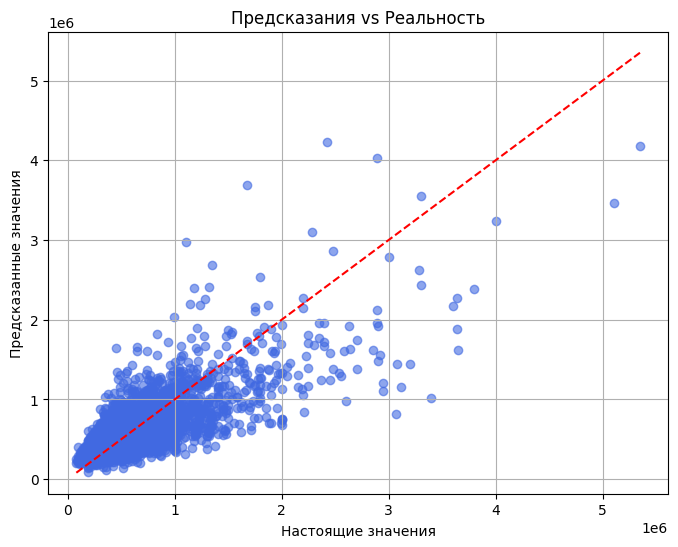

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # идеальная линия
plt.xlabel('Настоящие значения')
plt.ylabel('Предсказанные значения')
plt.title('Предсказания vs Реальность')
plt.grid(True)
plt.show()

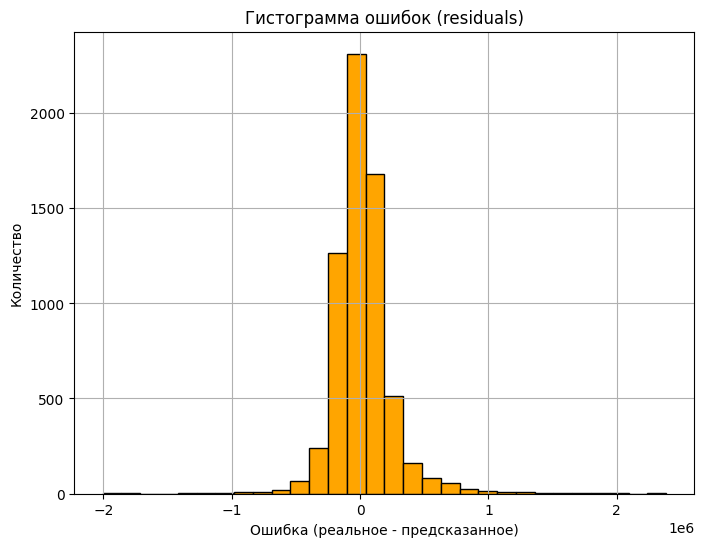

In [19]:
residuals = y_test - y_pred.flatten()

plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='orange', edgecolor='black')
plt.title('Гистограмма ошибок (residuals)')
plt.xlabel('Ошибка (реальное - предсказанное)')
plt.ylabel('Количество')
plt.grid(True)
plt.show()

Модель получлась слабовата. Попробуем это исправить

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
model_new = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_new

<Sequential name=sequential_4, built=True>

In [30]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_new.compile(optimizer=Adam(0.001), loss='mse')
model_new.fit(X_train_scaled, y_train, epochs=200, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 425309437952.0000 - val_loss: 389208932352.0000
Epoch 2/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 420519870464.0000 - val_loss: 362326949888.0000
Epoch 3/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - loss: 386564194304.0000 - val_loss: 303478341632.0000
Epoch 4/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 307443138560.0000 - val_loss: 223705382912.0000
Epoch 5/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - loss: 215917772800.0000 - val_loss: 147183894528.0000
Epoch 6/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - loss: 156366094336.0000 - val_loss: 96459137024.0000
Epoch 7/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - loss: 100229521408.0000 - val_loss: 71876730880.0000
Epoch 8/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - loss: 78489395200.0000 - val_loss: 62382649344.0000
Epoch 9/200
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - loss: 73870262272.0000 - val_loss: 58445299712.0000
Epoch 10/

In [31]:
y_pred_new = model_new.predict(X_test_scaled)

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step


In [32]:
mse = mean_squared_error(y_test, y_pred_new)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_new)
r2 = r2_score(y_test, y_pred_new)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.2f}")

MSE:  32530116608.00
RMSE: 180361.07
MAE:  108911.97
R²:   0.76


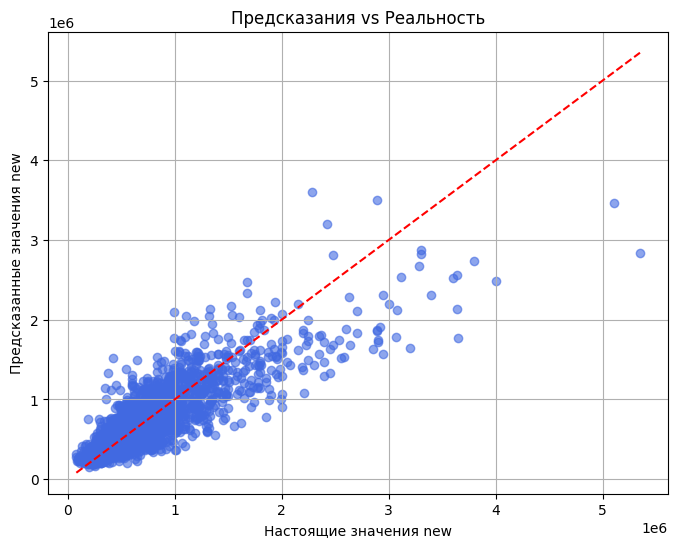

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_new, alpha=0.6, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # идеальная линия
plt.xlabel('Настоящие значения new')
plt.ylabel('Предсказанные значения new')
plt.title('Предсказания vs Реальность')
plt.grid(True)
plt.show()

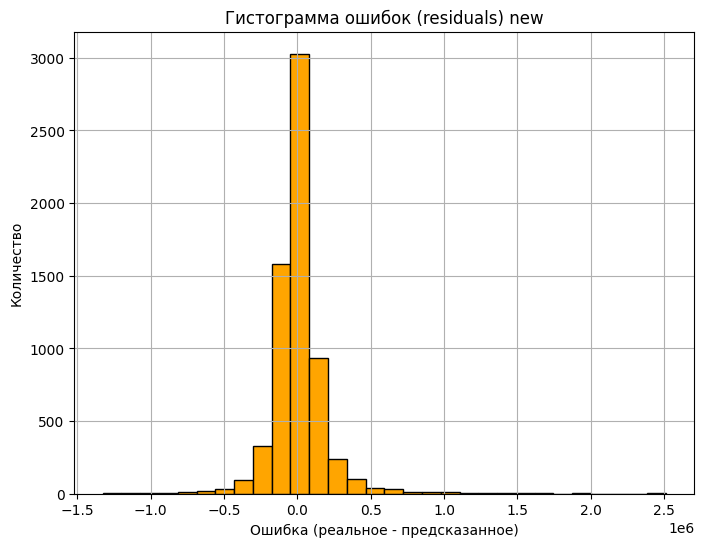

In [34]:
residuals = y_test - y_pred_new.flatten()

plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='orange', edgecolor='black')
plt.title('Гистограмма ошибок (residuals) new')
plt.xlabel('Ошибка (реальное - предсказанное)')
plt.ylabel('Количество')
plt.grid(True)
plt.show()

Применив другую стратегию к обучению модели, используя регляризацию и метод EarlyStop, а также нормализации данных, мы получили более умную и точную модель, хотя она и далека от идеала.